In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.planner import DiffuserPlanner, expand_spline_from_skip_list
from timeskip_diffuser.diffuser.reward import CompositeReward, GoalReachingReward, PathLengthPenalty, StartReachingReward, TotalTimeSkipPenalty, CurvaturePenalty, LogSkipReward
from timeskip_diffuser.datasets.point_maze.offline_skip.offline_skip import OfflineSkipDataset
import torch

In [2]:
dataset = OfflineSkipDataset(file_path="C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\datasets\\offline_datasets\\umaze_h32_mu1_sig1.npz", dataset_id="D4RL/pointmaze/umaze-v2", horizon=160)

In [3]:
len(dataset)

640006

In [4]:
net_type = "eqnet"

match net_type:
    case "eqnet":
        net_class = EqNet
        ckpt = "C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\pipelines\\runs\\umaze_eqnet_skip\\checkpoints\\diffuser_eqnet_epoch_20.pt"
    case "unet":
        net_class = TemporalUNet
        ckpt = "..."

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = net_class(
    state_dim=dataset.state_dim+1,
    time_dim=64,
)
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(model, diffusion, dataset, lr=1e-4, device=device)
trainer.load_checkpoint(ckpt)
planner = DiffuserPlanner(model, diffusion, dataset, device=device)

Using device: cuda


(32, 2)
(32, 1)


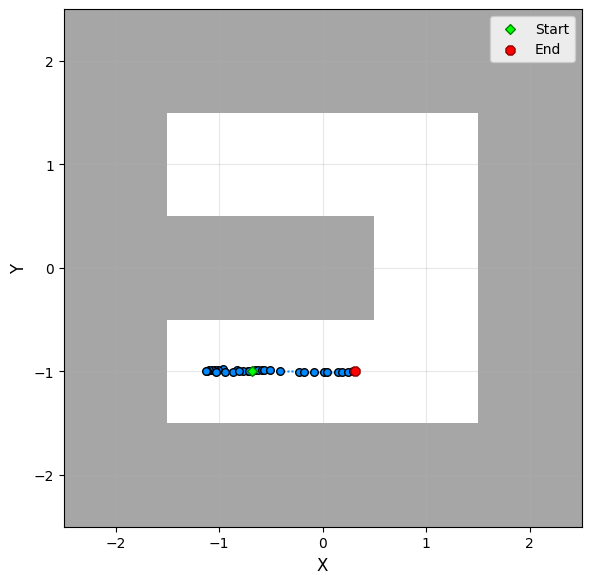

In [6]:
traj_norm = random.choice(dataset)
traj = dataset.denormalize(traj_norm)
dataset.visualize(traj)

In [11]:
current = np.array([-1, 1]) # traj[0][:2].copy()
goal = np.array([-1, -1]) # traj[-1][:2].copy()
print(current, goal)

[-1  1] [-1 -1]


In [80]:
reward_fn = CompositeReward([
    StartReachingReward(current, reward_scale=5.0),
    GoalReachingReward(goal, reward_scale=5.0),
    TotalTimeSkipPenalty(reward_scale=0.005),
    CurvaturePenalty(reward_scale=0.05),
    LogSkipReward(reward_scale=0),
])

traj_model = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=32,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)["coarse"]
print(traj_model)
print(f"Start (actual): {traj_model[0, :2]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(traj_model[0, :2] - current[:2]):.4f}")
print(f"End: {traj_model[-1, :2]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(traj_model[-1, :2] - goal):.4f}")

# Check for discontinuities (physics violations)
diffs = np.linalg.norm(traj_model[1:, :2] - traj_model[:-1, :2], axis=1)
max_jump = diffs.max()
print(f"Max step size: {max_jump:.4f}")
if max_jump > 0.2:  # Adjust threshold based on your maze
    print("  ⚠️  WARNING: Large discontinuity detected!")
else:
    print("  ✓ Trajectory appears continuous")

[[-1.0008163   0.9995947   4.403595  ]
 [-0.7954991   1.0011276   2.9801517 ]
 [-0.6351278   1.0055325   2.468284  ]
 [-0.4960508   1.0102755   2.692821  ]
 [-0.35511008  1.0135448   3.0599394 ]
 [-0.20951894  1.0116895   3.306872  ]
 [-0.05562767  0.9984447   3.4925337 ]
 [ 0.11370429  0.96210575  3.575634  ]
 [ 0.30085218  0.9120628   4.454556  ]
 [ 0.518569    0.8163095  12.696493  ]
 [ 0.7342246   0.6069971   5.88045   ]
 [ 0.84137845  0.35146913  4.14495   ]
 [ 0.86657894  0.14575747  5.4021635 ]
 [ 0.868007   -0.08981613  4.6627946 ]
 [ 0.86342514 -0.2701471   2.216199  ]
 [ 0.84109837 -0.3876582   1.8225334 ]
 [ 0.8166031  -0.51692843  2.0159469 ]
 [ 0.79318297 -0.6239505   2.2110438 ]
 [ 0.76795363 -0.7415697   2.9486237 ]
 [ 0.71310097 -0.8836495  12.339701  ]
 [ 0.49800164 -1.0266622   3.4974093 ]
 [ 0.3163763  -1.0684106   2.78856   ]
 [ 0.13647392 -1.0937883   3.0470302 ]
 [-0.0252451  -1.0888841   2.8883286 ]
 [-0.18722072 -1.1064328   2.4063218 ]
 [-0.34192    -1.0986345 

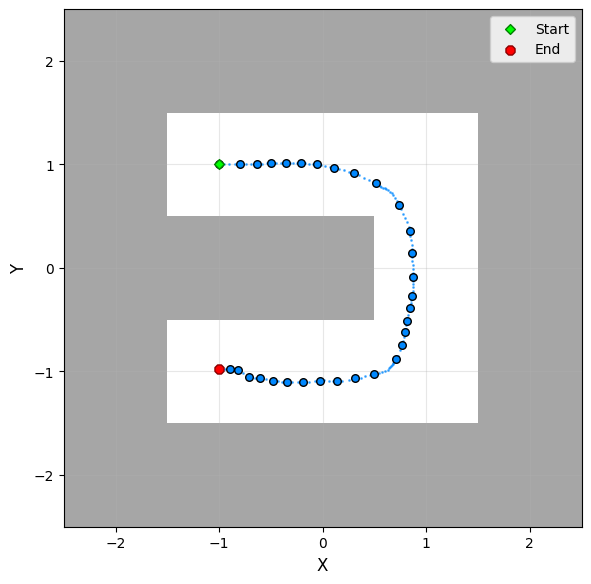

In [81]:
dataset.visualize(traj_model, save_file="longh_skip_good.png")

In [82]:
traj_model[:, 2].sum()

110.45455

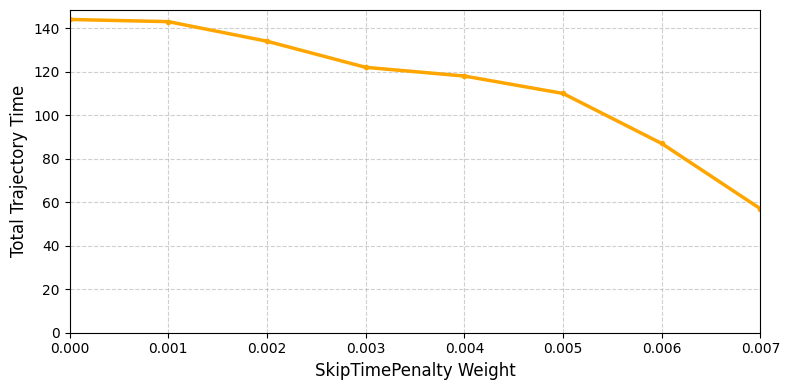

In [97]:
import matplotlib.pyplot as plt

x = [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007]
T = [144, 143, 134, 122, 118, 110, 87, 57]

plt.figure(figsize=(8, 4))

plt.plot(
    x, T,
    color='orange',
    linewidth=2.5,
    marker='.',
    markersize=6
)

plt.xlabel("SkipTimePenalty Weight", fontsize=12)
plt.ylabel("Total Trajectory Time", fontsize=12)
plt.xlim(left=0, right=0.007)
plt.ylim(bottom=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("skip_reward.png")

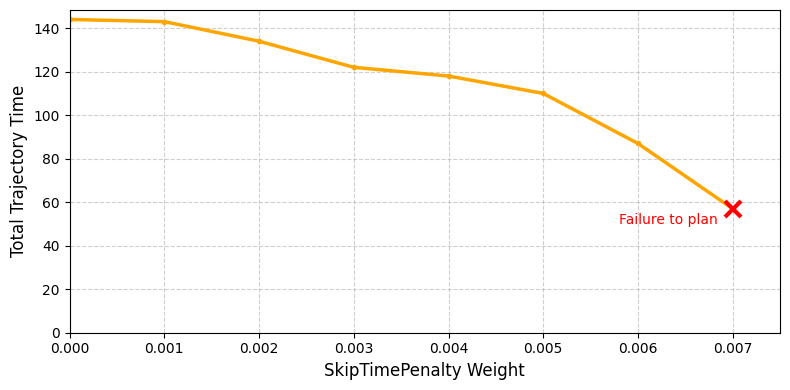

In [108]:
import matplotlib.pyplot as plt

x = [0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007]
T = [144, 143, 134, 122, 118, 110, 87, 57]

plt.figure(figsize=(8, 4))

plt.plot(
    x, T,
    color='orange',
    linewidth=2.5,
    marker='.',
    markersize=6
)

# Red X at failure point
plt.plot(
    0.007, 57,
    marker='x',
    color='red',
    markersize=12,
    markeredgewidth=3
)

# Optional annotation
plt.annotate(
    "Failure to plan",
    xy=(0.007, 57),
    xytext=(0.0058, 50),
    # arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red"
)

plt.xlabel("SkipTimePenalty Weight", fontsize=12)
plt.ylabel("Total Trajectory Time", fontsize=12)
plt.xlim(left=0, right=0.0075)
plt.ylim(bottom=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("skip_reward_2.png", dpi=300)
plt.show()